In [3]:
import os
from SSD_eval.SSD_utils import get_project_root
from pathlib import Path
import sys
from ipywidgets import interact

os.chdir(get_project_root())

ssd_eval_path = str(Path.cwd() / "SSD_eval")
if ssd_eval_path not in sys.path:
    sys.path.insert(0, ssd_eval_path)

from SSD_eval.SSD_test_utils import *

%matplotlib widget

Loading model from checkpoint: checkpoints/syn/control_biased_00/checkpoints/last.ckpt
Loaded default weights from checkpoints/syn/control_biased_00/checkpoints/last.ckpt
tensor([[ 1.0000,  0.0000,  0.0000, -0.4444, -0.1111, -0.7143, -0.6711,  0.7413,
          0.6235,  0.4510,  0.8431],
        [ 0.0000,  1.0000,  0.0000,  0.8889,  0.5556,  0.7143,  0.2991, -0.9542,
         -0.5059, -0.6078,  0.0039],
        [ 1.0000,  0.0000,  0.0000, -0.7778, -0.6667, -0.7143,  0.6047, -0.7965,
         -0.7882, -0.0196, -0.6392]], device='cuda:0')
tensor([[ 3.2362e+00, -3.4510e+00, -7.2748e+00, -4.7387e-01,  4.0664e-02,
         -6.9776e-01, -5.6638e-01,  5.4615e-01,  6.1635e-01,  4.7468e-01,
          8.5613e-01],
        [-2.5152e+00,  4.3334e+00, -8.1170e+00,  8.7218e-01,  6.8515e-01,
          7.6358e-01,  3.8758e-01, -9.7205e-01, -5.7400e-01, -6.3878e-01,
         -8.3093e-04],
        [ 4.7458e+00, -3.6487e+00, -9.4562e+00, -8.2387e-01, -8.2197e-01,
         -7.5860e-01,  5.4964e-01, -6.712

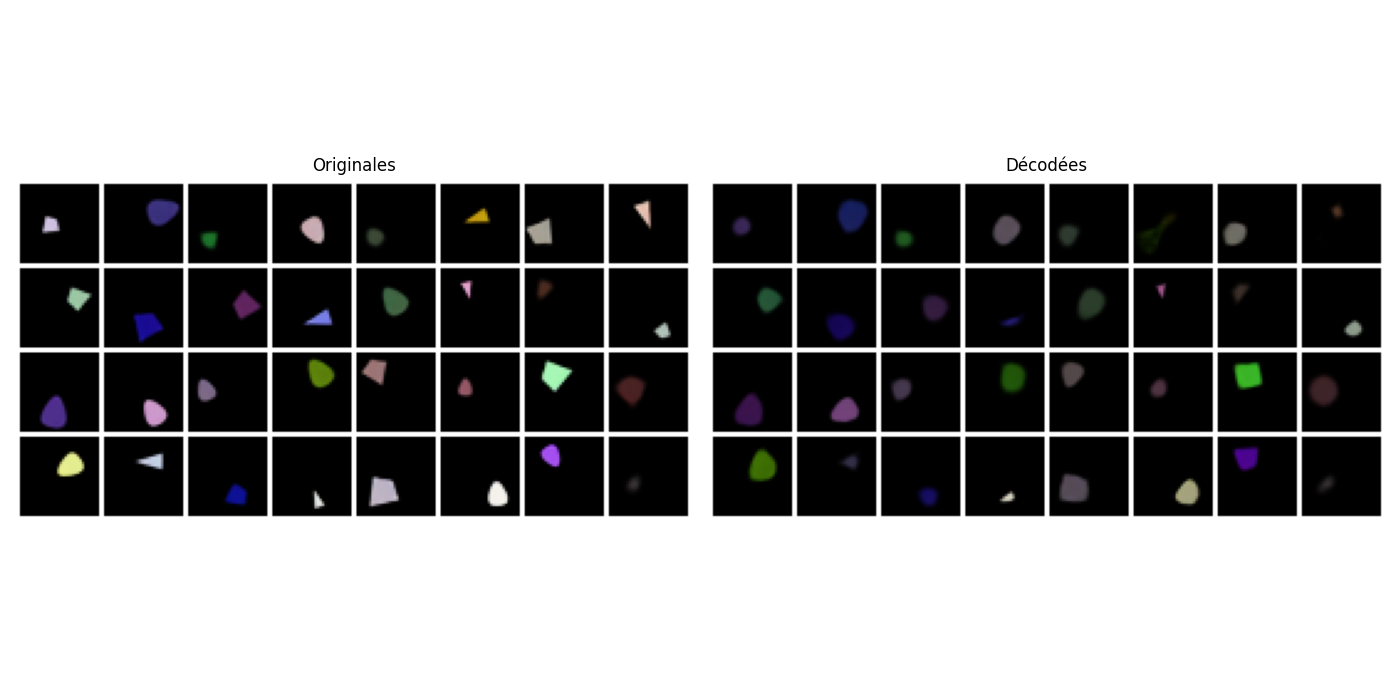

In [47]:
condition = "control"
data = "biased_00"

n_samples = 32
show_results_fusion = True
fusion_attr_weight = 1.0

project_name = "syn"
experiment_name = f"{condition}_{data}"


training_params = get_training_params(project_name, experiment_name)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

global_workspace = get_global_workspace(project_name, experiment_name)
data_module = get_data_module(project_name,  experiment_name)
train_samples = get_data_samples(data_module, n_samples)
data_translated = get_data_translated(global_workspace, train_samples, n_samples, fusion_attr_weight, show_results_fusion)

print(data_translated["train_attr"][0:3])
print(data_translated["attr_decoded"][0:3])
plot_original_translated_comparison(data_translated["train_images"], data_translated["images_decoded"])

In [ ]:
@interact(
    cat=["Triangle", "Egg", "Diamond"],
    x=(0, 1, 0.1),
    y=(0, 1, 0.1),
    rot=(0, 1, 0.1),
    size=(0, 1, 0.1),
    color_r=(0, 1, 0.1),
    color_g=(0, 1, 0.1),
    color_b=(0, 1, 0.1),
)
def play_with_gw(
    cat: str = "Triangle",
    x: float = 0.5,
    y: float = 0.5,
    rot: float = 0.5,
    size: float = 0.5,
    color_r: float = 1,
    color_g: float = 0,
    color_b: float = 0,
):
    original_image = get_image(cat, x, y, size, rot, color_r, color_g, color_b)
    decoded_image = get_decoded_image(cat, x, y, size, rot, color_r, color_g, color_b, training_params, device, global_workspace)
    plot_interactive(original_image, decoded_image)



interactive(children=(Dropdown(description='cat', options=('Triangle', 'Egg', 'Diamond'), value='Triangle'), F…